In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, f1_score

import os

In [2]:
df = pd.read_csv("../data/diabetes.csv")

print(df.shape)

df.head()

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
batch_size = len(df) // 10

batches = []

for i in range(10):

    start = i * batch_size

    if i == 9:
        batch = df.iloc[start:]
    else:
        batch = df.iloc[start:start + batch_size]

    batches.append(batch)

print("Number of batches:", len(batches))
print(type(batches[0]))

Number of batches: 10
<class 'pandas.DataFrame'>


In [5]:
results = []

In [6]:
for i in range(1, len(batches)):

    print(f"Running Batch {i}")

    train_data = pd.concat(batches[:i], ignore_index=True)
    test_data = batches[i]

    X_train = train_data.drop("Outcome", axis=1)
    y_train = train_data["Outcome"]

    X_test = test_data.drop("Outcome", axis=1)
    y_test = test_data["Outcome"]

    scaler = MinMaxScaler()

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    model = tf.keras.Sequential([
        tf.keras.layers.Dense(
            64,
            activation='relu',
            input_shape=(X_train.shape[1],)
        ),

        tf.keras.layers.Dense(
            32,
            activation='relu'
        ),

        tf.keras.layers.Dense(
            1,
            activation='sigmoid'
        )
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        X_train,
        y_train,
        epochs=20,
        batch_size=32,
        verbose=0
    )

    y_prob = model.predict(X_test, verbose=0)

    y_pred = (y_prob > 0.5).astype(int)

    acc = accuracy_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    results.append([
        i,
        acc,
        f1,
        0.5
    ])

Running Batch 1


c:\Users\neeli\OneDrive\Desktop\disease-ai-intern\.venv311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Running Batch 2


c:\Users\neeli\OneDrive\Desktop\disease-ai-intern\.venv311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Running Batch 3


...

c:\Users\neeli\OneDrive\Desktop\disease-ai-intern\.venv311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Running Batch 8


c:\Users\neeli\OneDrive\Desktop\disease-ai-intern\.venv311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Running Batch 9


c:\Users\neeli\OneDrive\Desktop\disease-ai-intern\.venv311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Batch",
        "Accuracy",
        "F1",
        "Threshold"
    ]
)

results_df

,Batch,Accuracy,F1,Threshold
0,1,0.736842,0.333333,0.5
1,2,0.578947,0.272727,0.5
2,3,0.605263,0.375000,0.5
3,4,0.763158,0.640000,0.5
4,5,0.723684,0.553191,0.5
5,6,0.789474,0.500000,0.5
6,7,0.802632,0.651163,0.5
7,8,0.763158,0.608696,0.5
8,9,0.833333,0.750000,0.5


In [8]:
os.makedirs("../results/week5", exist_ok=True)

results_df.to_csv(
    "../results/week5/adaptive_results.csv",
    index=False
)

print("CSV Saved")

CSV Saved


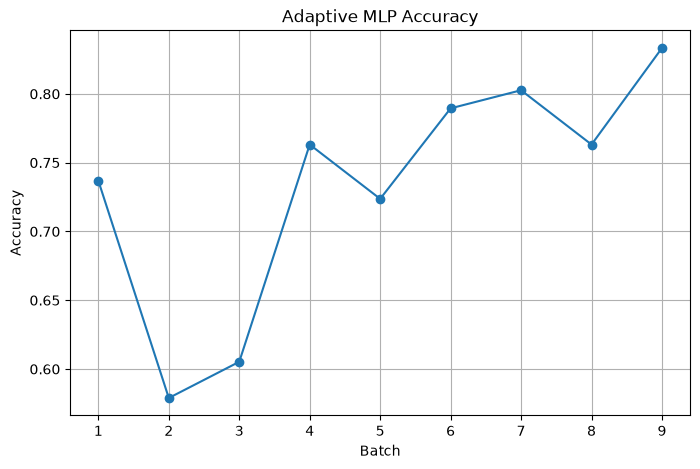

In [9]:
plt.figure(figsize=(8,5))

plt.plot(
    results_df["Batch"],
    results_df["Accuracy"],
    marker="o"
)

plt.xlabel("Batch")
plt.ylabel("Accuracy")
plt.title("Adaptive MLP Accuracy")

plt.grid(True)

plt.savefig(
    "../results/week5/adaptive_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

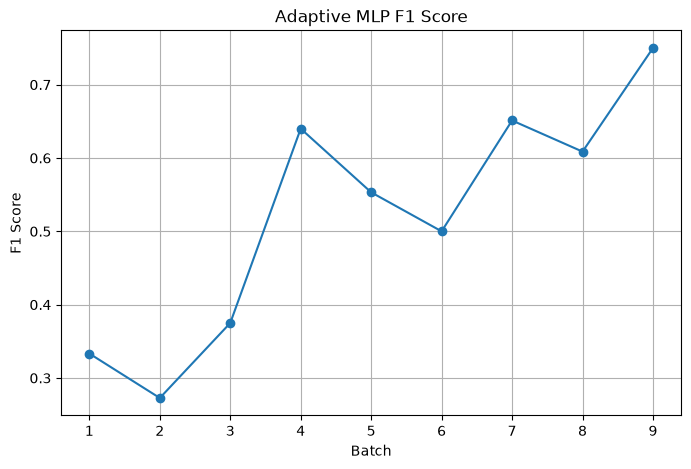

In [10]:
plt.figure(figsize=(8,5))

plt.plot(
    results_df["Batch"],
    results_df["F1"],
    marker="o"
)

plt.xlabel("Batch")
plt.ylabel("F1 Score")
plt.title("Adaptive MLP F1 Score")

plt.grid(True)

plt.savefig(
    "../results/week5/adaptive_f1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()